อ้างอิง
https://magazine.sebastianraschka.com/p/coding-the-kv-cache-in-llms

มาดูการ generate token ต่อ token ปกติ

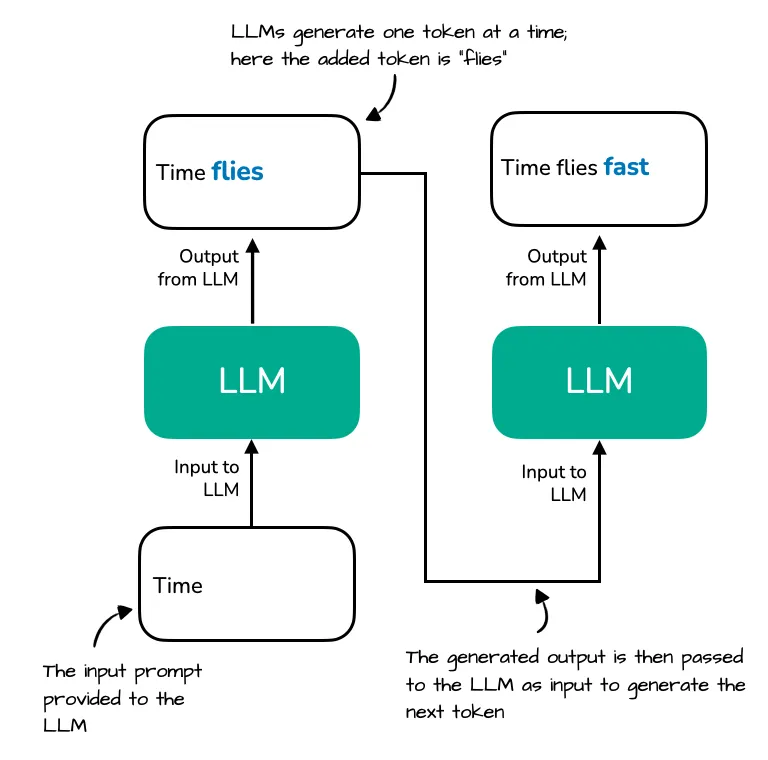

อย่างสมมติ llm จะ generate คำว่า time flies
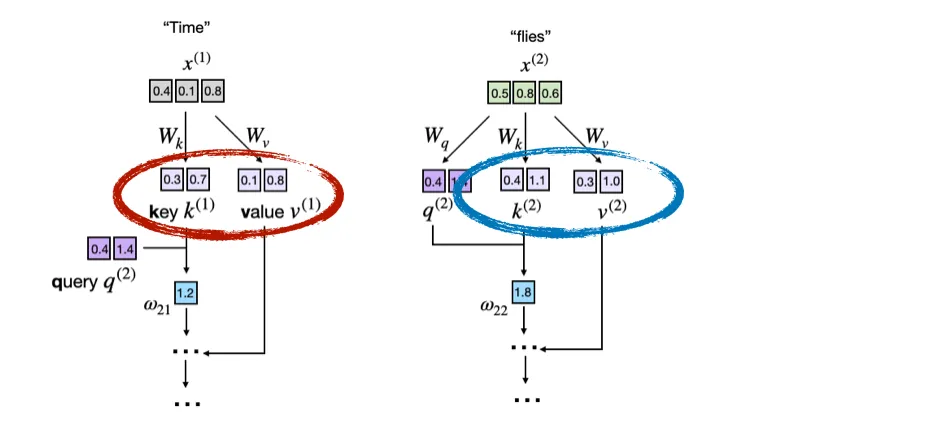

สิ่งที่ภาพนี้ไม่ได้บอกคือการที่้ model generate คำว่า 'Time' ตัว weight ตั้งต้นก็จะเป็นตามด้านซ้าย
เเล้วพอจะ generate คำว่า flies ออกมา มันไม่ได้เเค่ว่าเข้า q@kt.. เเล้วออกมาเป้น flies เเต่การคำนวรที่นำมาซึ่ง Time ก้จะเกิดขึ้นอีกรอบ (i.e. ทุกตัวเลขในภาพถูกคำนวณ)
เเละเมื่อจะ generate คำว่า fast ใหม่

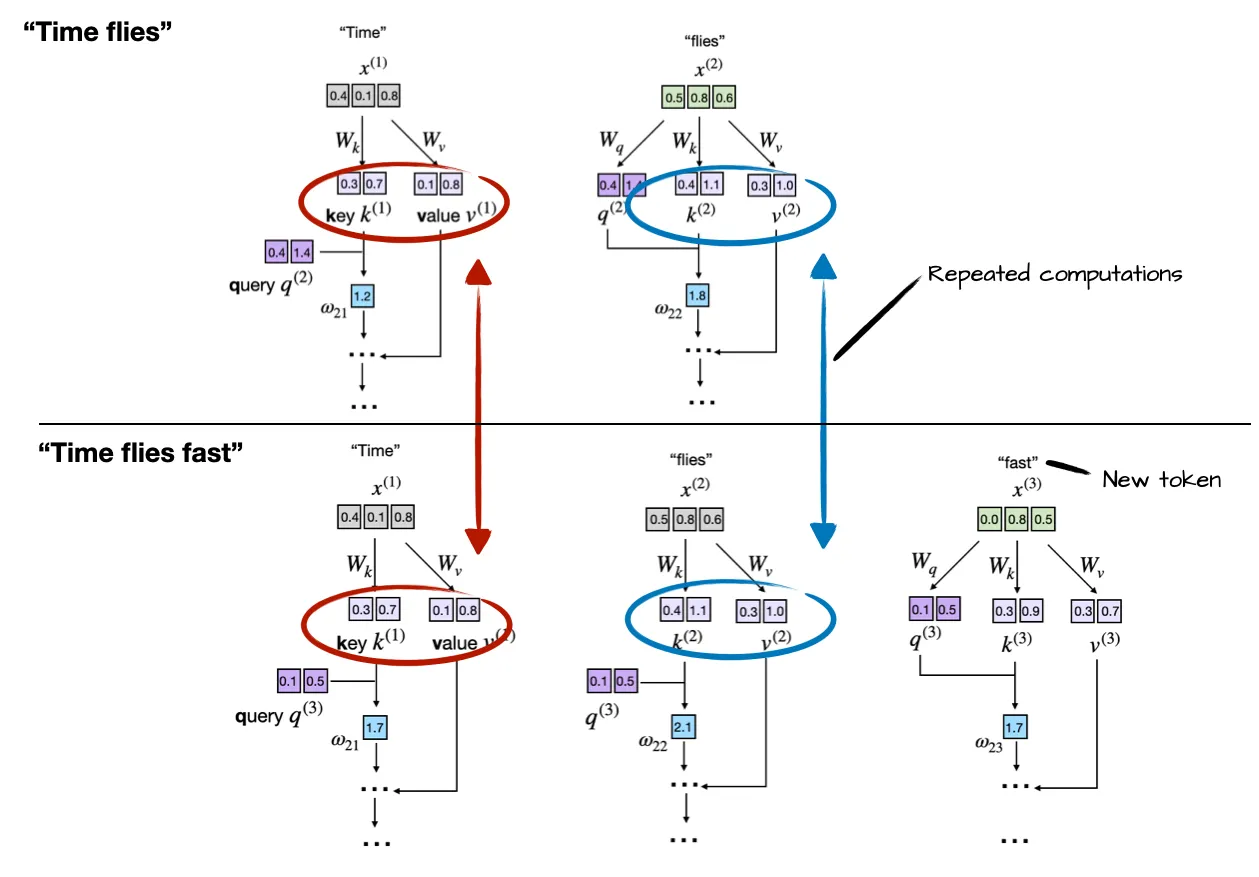

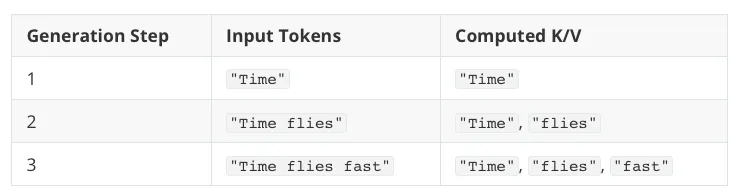

เราเลยจะทำการ cache ไว้เพราะยังไงมันก้เหมือนๆเดิมคือเซฟมันไว้ในตัวเเปรนึงเเล้วให้มันคำนวรเฉพาะของใหม่

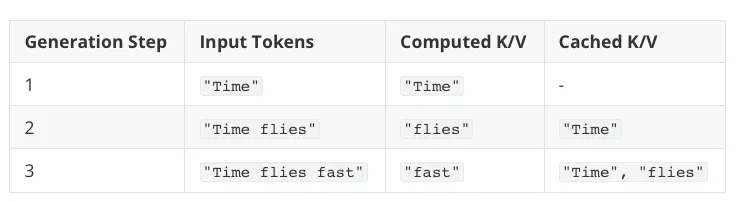

สถาปัตยกรรมดดนรวมจึงเป็น
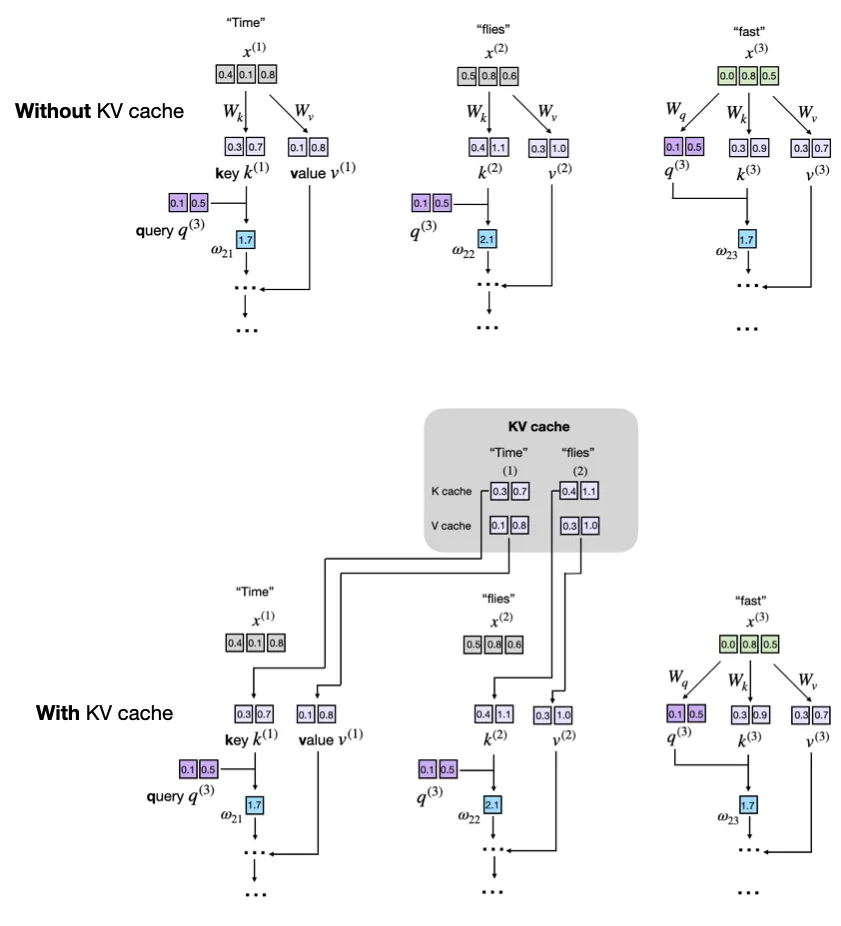

ทุก output token $t_{out,i}$ จะถูก store ไว้ในตัวเเปรตัวนึงซ้ำๆ ซึ่งเเน่นอนว่าในการ implement มันจะต้องถูกเก็บไว้ทันทีที่ attention weight โดน calculate
ต่อมาจะลองทำการ implement

In [24]:
import torch
import torch.nn as nn

torch.manual_seed(0)

vocab_size = 10
d_model    = 8
seq        = torch.tensor([[1, 0, 3]])

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)
        self.register_buffer("cache_k", None)     #.register_buffer คือมีไว้เเต่ตัว optimize ไม่รุ้จัก ถ้าเทรนค่านี้่จะไม่โดน update เเต่เราไม่ได้จะเทรน เเล้วตั้งชื่อตัวเเปรเฉยๆ
        self.register_buffer("cache_v", None)

    def reset_cache(self):       #มีไว้เพราะว่าการทำ KV cache เราทำต่อ 1 respond ถ้าเราเซฟไว้ พอเราทำอีก responseต่อถ้าไม่รีเซ้ตมันจะ attendต่อ k v เก่า
        self.cache_k = None
        self.cache_v = None

    def forward(self, x, use_cache=False):
        q      = self.W_q(x)
        k_new  = self.W_k(x)
        v_new  = self.W_v(x)
        if use_cache:                              #####การทำ cache จะเป็นตาม diagram คือเป็น if-else ถ้าเป็นตัวเเรกก็เก็บไว้ ถ้าเป็นตัวถัดไปก้ concat
            if self.cache_k is None:   # สำหรับ KV คู่เเรก
                self.cache_k = k_new
                self.cache_v = v_new
            else:
                print(f"k_new (new row):\n{k_new}")
                self.cache_k = torch.cat([self.cache_k, k_new], dim=1) # noteว่าสังเกตว่าเมื่อ concat เเล้ว dimen จะเปลี่ยน-> เราคง dim =1 ไว้
                self.cache_v = torch.cat([self.cache_v, v_new], dim=1)
                print(f"cache_k after cat:\n{self.cache_k}")
            k, v = self.cache_k, self.cache_v    # จะได้ใหม่ + เก่า
        else:
            k, v = k_new, v_new
        scale  = d_model ** 0.5
        scores = (q @ k.transpose(-2, -1)) / scale  # (B, T_q, T_k)
        T_q, T_k = scores.shape[-2], scores.shape[-1]
        if T_q > 1:
            mask = torch.triu(torch.ones(T_q, T_k), diagonal=1).bool()
            scores = scores.masked_fill(mask, float('-inf'))

        attn = scores.softmax(dim=-1)
        out  = attn @ v
        return self.W_o(out)


สังเกตว่า concat เเล้ว size ควรเพิ่ม เเล้วจะไป matmul กับ q ได้ไง?

In [25]:
import torch

torch.manual_seed(0)
cache_k = torch.randn(1, 3, 8)
print("cache_k shape before:", cache_k.shape)  # (1, 3, 8)
print(cache_k)

k_new = torch.randn(1, 1, 8)
print("\nk_new shape:", k_new.shape)  # (1, 1, 8)
print(k_new)

cache_k = torch.cat([cache_k, k_new], dim=1)
print("\ncache_k shape after:", cache_k.shape)  # (1, 4, 8)
print(cache_k)

print("\nlast row equals k_new:", torch.allclose(cache_k[:, -1:, :], k_new))

q = torch.randn(1, 1, 8)
scores = q @ cache_k.transpose(-2, -1)  #(1, 1, 8) @ (1, 8, 4)
print(scores)
print(f"\nget the size of score being{scores.shape}")

cache_k shape before: torch.Size([1, 3, 8])
tensor([[[-1.1258, -1.1524, -0.2506, -0.4339,  0.8487,  0.6920, -0.3160,
          -2.1152],
         [ 0.4681, -0.1577,  1.4437,  0.2660,  0.1665,  0.8744, -0.1435,
          -0.1116],
         [ 0.9318,  1.2590,  2.0050,  0.0537,  0.6181, -0.4128, -0.8411,
          -2.3160]]])

k_new shape: torch.Size([1, 1, 8])
tensor([[[ 0.3704,  1.4565,  0.9398,  0.7748,  0.1919,  1.2638, -1.2904,
          -0.7911]]])

cache_k shape after: torch.Size([1, 4, 8])
tensor([[[-1.1258, -1.1524, -0.2506, -0.4339,  0.8487,  0.6920, -0.3160,
          -2.1152],
         [ 0.4681, -0.1577,  1.4437,  0.2660,  0.1665,  0.8744, -0.1435,
          -0.1116],
         [ 0.9318,  1.2590,  2.0050,  0.0537,  0.6181, -0.4128, -0.8411,
          -2.3160],
         [ 0.3704,  1.4565,  0.9398,  0.7748,  0.1919,  1.2638, -1.2904,
          -0.7911]]])

last row equals k_new: True
tensor([[[1.9829, 1.2991, 1.2062, 1.7973]]])

get the size of score beingtorch.Size([1, 1, 4])


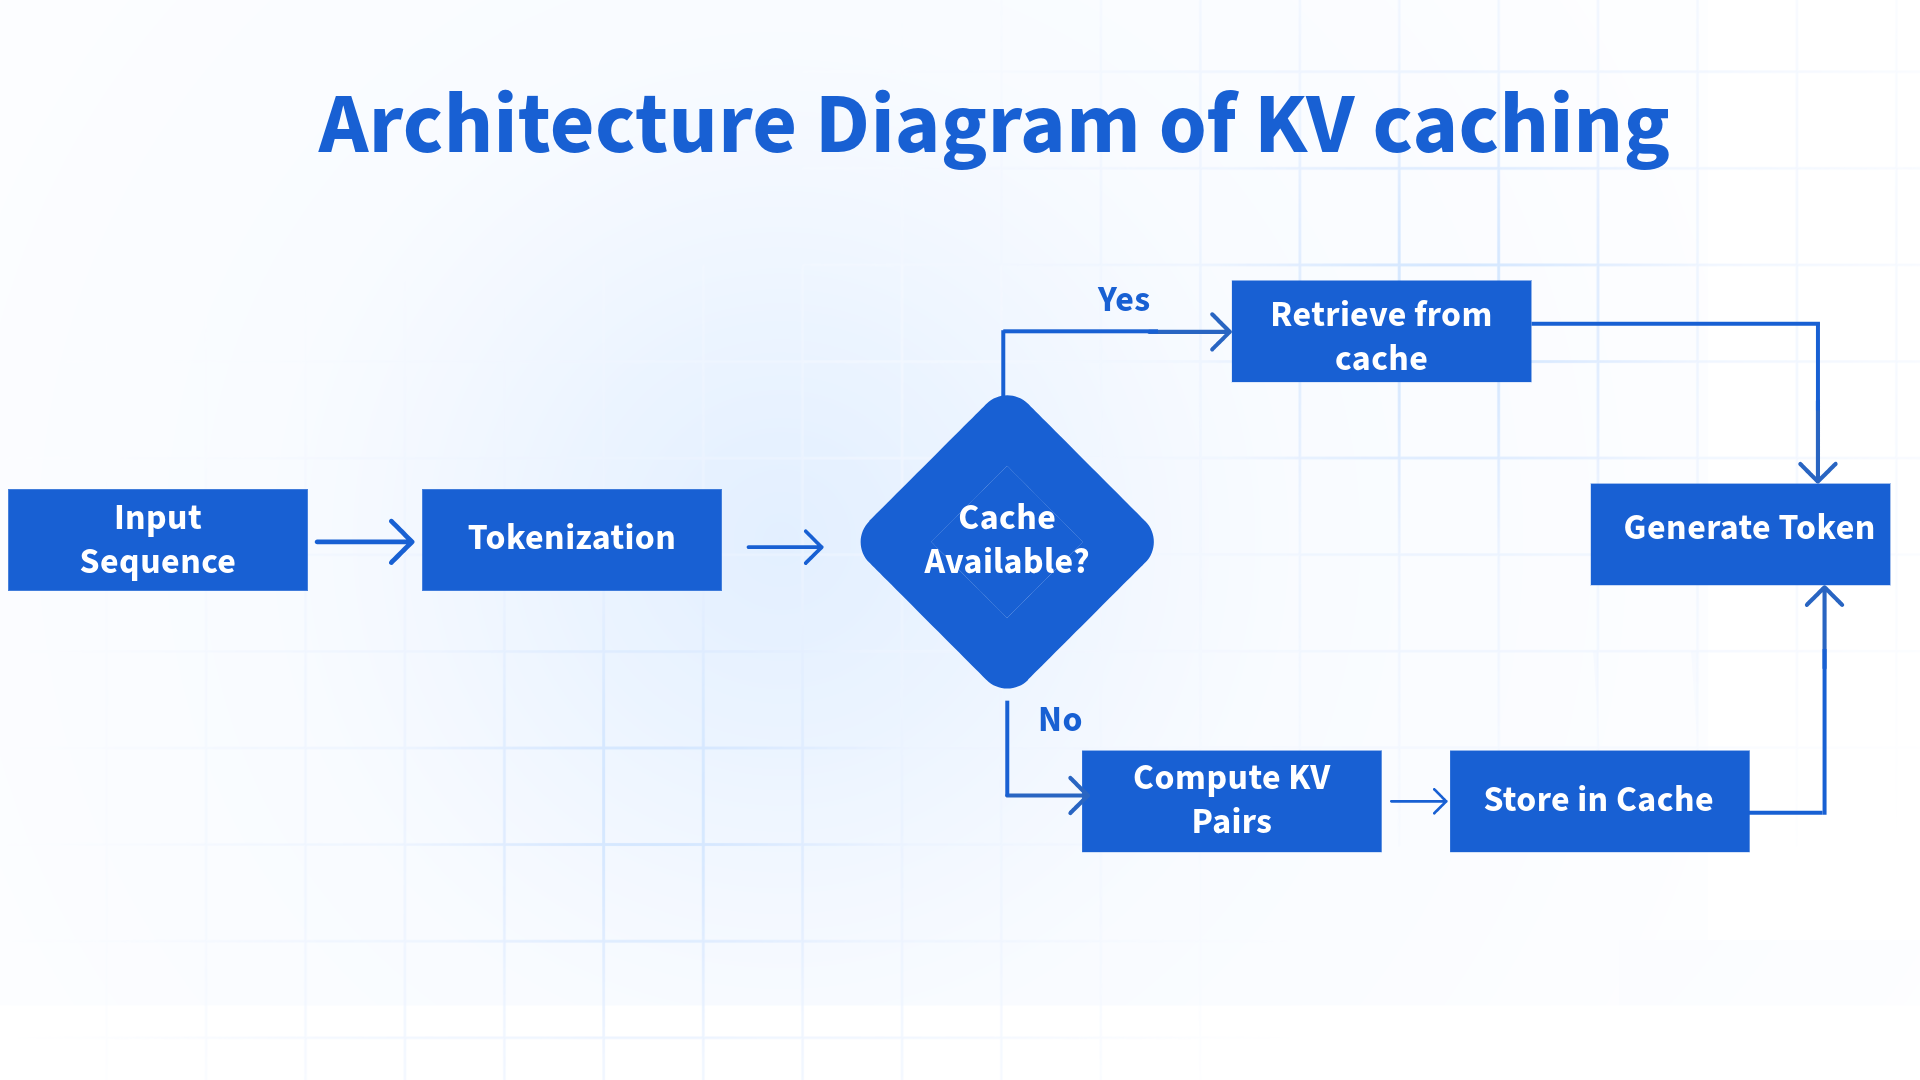

In [26]:
class TinyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, d_model)
        self.attn    = CausalSelfAttention(d_model)
        self.unembed = nn.Linear(d_model, vocab_size, bias=False)
        self.current_pos = 0
    def reset_kv_cache(self):
        self.attn.reset_cache()
        self.current_pos = 0
    def forward(self, idx, use_cache=False):
        B, T = idx.shape
        x = self.embed(idx)                      # (B, T, d_model)
        if use_cache:
            pos = torch.arange(self.current_pos, self.current_pos + T)
            self.current_pos += T
        else:
            pos = torch.arange(0, T)
        x = x + pos.float().unsqueeze(-1) * 0.01

        x = x + self.attn(x, use_cache=use_cache)
        return self.unembed(x)

In [27]:
model = TinyModel()
model.eval()
with torch.no_grad():
    model.reset_kv_cache()
    logits   = model(seq, use_cache=True)            # (1, 3, vocab_size)
    next_tok = logits[:, -1, :].argmax(-1, keepdim=True)  # (1, 1)
    print(f"token y = id {next_tok.item()}")

    for name in ['z', 'w']:
        logits   = model(next_tok, use_cache=True)   # (1, 1, vocab_size) only!
        next_tok = logits[:, -1, :].argmax(-1, keepdim=True)
        print(f"token {name} = id {next_tok.item()}  | cache size: {model.attn.cache_k.shape[1]}")

token y = id 1
k_new (new row):
tensor([[[-0.2419,  0.4243, -0.7620, -0.2072, -0.1168,  0.5068, -0.1164,
          -0.1106]]])
cache_k after cat:
tensor([[[-0.2419,  0.4350, -0.7685, -0.2093, -0.1064,  0.5110, -0.1185,
          -0.0917],
         [-1.2216, -0.6490,  0.6207,  0.1854, -0.3837, -1.1122, -0.1323,
          -1.6816],
         [-0.1184,  0.2253, -0.0497, -0.1213, -0.1445, -0.1298, -0.3941,
          -0.0084],
         [-0.2419,  0.4243, -0.7620, -0.2072, -0.1168,  0.5068, -0.1164,
          -0.1106]]])
token z = id 9  | cache size: 4
k_new (new row):
tensor([[[-0.2071,  0.1178,  0.2105,  0.5224,  0.6142,  0.1695,  0.7622,
           0.7313]]])
cache_k after cat:
tensor([[[-0.2419,  0.4350, -0.7685, -0.2093, -0.1064,  0.5110, -0.1185,
          -0.0917],
         [-1.2216, -0.6490,  0.6207,  0.1854, -0.3837, -1.1122, -0.1323,
          -1.6816],
         [-0.1184,  0.2253, -0.0497, -0.1213, -0.1445, -0.1298, -0.3941,
          -0.0084],
         [-0.2419,  0.4243, -0.7620, -

จะเห็นว่า cache ที๋โดน store ตอนเเรกคือ

tensor([[[-0.2419,  0.4350, -0.7685, -0.2093, -0.1064,  0.5110, -0.1185,
          -0.0917],
         [-1.2216, -0.6490,  0.6207,  0.1854, -0.3837, -1.1122, -0.1323,
          -1.6816],
         [-0.1184,  0.2253, -0.0497, -0.1213, -0.1445, -0.1298, -0.3941,
          -0.0084],
         [-0.2419,  0.4243, -0.7620, -0.2072, -0.1168,  0.5068, -0.1164,
          -0.1106]]])

เเละเมื่อคิดใหม่จะเป็น

 [-0.2071,  0.1178,  0.2105,  0.5224,  0.6142,  0.1695,  0.7622,
           0.7313]

  ซึ่งจะคิดเเค่นั้น โดยจะช่วยการคำนวณอย่างมากจาก
  $1+2+...+n = O(n^2)$
  เป็น
  $1+1+1+....+1 = O(n)$